# Đánh giá rPPG (eval-only) — KHÔNG train lại

## 📋 Hướng dẫn Input Kaggle

Trước khi chạy, hãy vào **Data → Add Input** và thêm 2 dataset sau:

| Input Dataset | Chứa gì | Biến đường dẫn |
| :--- | :--- | :--- |
| `thinhphan272/ffpp-c23-rppg-cache` | Dữ liệu tín hiệu rPPG đã tiền xử lý (manifest, frames) | `CACHE_DIR` |
| `thinhphan272/trained-dffusionmodel-rppg-pth` | `rppg_can_best.pth` (checkpoint) + `train_history.csv` | `BEST_PATH`, `TRAIN_HISTORY_CSV` |

> ⚠️ Nếu tên dataset khác, sửa lại đường dẫn tương ứng trong Mục 1 (Cell cấu hình).

---

**Lý do có notebook này:** bản train đầy đủ bị lỗi `NameError: name 'plt' is not defined` ngay ở
bước vẽ Confusion Matrix — do tôi quên `import matplotlib.pyplot as plt` khi viết lại cell test
(bản gốc chỉ import ở cell vẽ training-curve, chạy SAU cell test, nên khi thêm code vẽ hình vào
cell test lại thiếu import). Toàn bộ **quá trình train đã chạy xong và checkpoint đã lưu**
(`rppg_can_best.pth`, val_auc=0.9651) — lỗi chỉ xảy ra ở bước vẽ hình SAU KHI đã tính xong hết
Accuracy/AUC/EER/Confusion Matrix, nên **không cần train lại**.

## Cách dùng
1. Nếu bạn **vẫn đang ở cùng session Kaggle** (kernel chưa tắt): giữ nguyên `BEST_PATH` mặc định
   bên dưới (`/kaggle/working/rppg_can_branch/rppg_can_best.pth`), chạy notebook này — nó sẽ
   dùng lại checkpoint đã có trong `/kaggle/working/`.
2. Nếu bạn đã **đóng session cũ / mở notebook mới**: add `rppg_can_best.pth` (và `train_history.csv`
   nếu muốn) làm Kaggle Input Dataset mới, rồi sửa `BEST_PATH` trỏ đúng đường dẫn.

⚠️ **Về `gpu_hours`**: notebook eval-only này KHÔNG có thông tin thời gian train thật (dữ liệu đó
chỉ tồn tại trong session cũ đã đóng, chưa kịp lưu vào CSV). Nếu bạn nhớ tổng thời gian chạy
(Kaggle thường hiển thị ở tab Output/Version của lần chạy trước), điền vào `MANUAL_GPU_HOURS`
bên dưới; nếu không nhớ, để `None` — cột `gpu_hours` sẽ ghi `NaN`, không ảnh hưởng gì tới AUC/EER/
breakdown, chỉ thiếu 1 con số tham khảo trong bảng so sánh cuối.


## 1. Cấu hình (khớp đúng thông số đã dùng lúc train)

In [1]:
import os, glob, time, random, copy, json, math
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt   # << ĐÂY LÀ DÒNG BỊ THIẾU GÂY LỖI NameError Ở BẢN TRƯỚC
import warnings
warnings.filterwarnings("ignore")

# ==================== ĐƯỜNG DẪN ====================
CACHE_DIR      = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"
MANIFEST_CSV   = os.path.join(CACHE_DIR, "manifest_processed.csv")
OLD_PREFIX     = "/kaggle/working/ffpp_c23_rppg_cache"
assert os.path.isdir(CACHE_DIR), f"Không tìm thấy CACHE_DIR: {CACHE_DIR}"

# SỬA đường dẫn này nếu bạn đang ở session/notebook mới (xem hướng dẫn ở Mục 0)
BEST_PATH = "/kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/rppg_can_best.pth"
TRAIN_HISTORY_CSV = os.path.join(os.path.dirname(BEST_PATH), "train_history.csv")  # CSV log training
MANUAL_GPU_HOURS = 11.5   # DA DIEN: nguoi dung cho biet thoi gian train that = 11h30p

# ==================== THAM SỐ (PHẢI KHỚP Y HỆT lúc train, chỉ dùng cho kiến trúc + preprocessing) ====================
CAN_IMG_SIZE     = 96
CLIP_LEN_EVAL    = 96
MIN_FRAMES       = 50
DIFF_EPS         = 0.01
DROPOUT          = 0.3
SEED             = 42
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "/kaggle/working/rppg_can_branch"
os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CHECKPOINT_CRITERION = "val_auc"
TTA_USED = "hflip"

print("Device:", DEVICE)
assert os.path.exists(BEST_PATH), f"KHÔNG tìm thấy checkpoint tại {BEST_PATH} -- sửa lại BEST_PATH ở trên"
print("Checkpoint:", BEST_PATH, "| size:", round(os.path.getsize(BEST_PATH)/1e6, 1), "MB")


Device: cuda
Checkpoint: /kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/rppg_can_best.pth | size: 19.1 MB


## 2. Đọc manifest, lấy tập test

In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest["out_dir"] = manifest["out_dir"].str.replace(OLD_PREFIX, CACHE_DIR, regex=False)

manifest_ok = manifest[
    manifest["status"].isin(["ok", "skip_exists", "partial"]) & (manifest["n_frames"] >= MIN_FRAMES)
].reset_index(drop=True)

test_df = manifest_ok[manifest_ok.split == "test"].reset_index(drop=True)
print(f"Test videos: {len(test_df)}")
print(test_df.groupby(["label", "method"])["video_id"].count())


Test videos: 700
label  method        
0      original          140
1      Deepfakes         140
       Face2Face         140
       FaceSwap          140
       NeuralTextures    140
Name: video_id, dtype: int64


## 3. Dataset (chỉ cần bản Eval, không cần Train/Sampler)

In [3]:
def load_and_resize(path, size=CAN_IMG_SIZE):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (size, size)).astype(np.float32)


def compute_normalized_diff(curr, prev, eps=DIFF_EPS):
    c = curr / 255.0
    p = prev / 255.0
    return (c - p) / (c + p + eps)


class CANEvalDataset(Dataset):
    def __init__(self, df, clip_len=CLIP_LEN_EVAL, img_size=CAN_IMG_SIZE):
        self.rows = df.reset_index(drop=True)
        self.clip_len = clip_len
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        paths = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        n = len(paths)
        need = self.clip_len + 1
        start = max(0, (n - need) // 2)

        apps, mots = [], []
        prev = None
        for i in range(min(need, n)):
            fi = min(start + i, n - 1)
            img = load_and_resize(paths[fi], self.img_size)
            if prev is not None:
                apps.append(img / 255.0)
                mots.append(compute_normalized_diff(img, prev))
            prev = img

        while len(apps) < self.clip_len:
            apps.append(apps[-1] if apps else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
            mots.append(mots[-1] if mots else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))

        app_t = torch.from_numpy(np.stack(apps[:self.clip_len])).permute(0, 3, 1, 2).float()
        mot_t = torch.from_numpy(np.stack(mots[:self.clip_len])).permute(0, 3, 1, 2).float()
        label = torch.tensor(row.label, dtype=torch.float32)
        return app_t, mot_t, label, row.video_id


test_ds = CANEvalDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test: {len(test_ds)} video")


Test: 700 video


## 4. Kiến trúc model (copy nguyên xi từ notebook train — PHẢI khớp 100% để load đúng state_dict)

In [4]:
class SqueezeExcitation(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch // reduction), nn.ReLU(),
            nn.Linear(ch // reduction, ch), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)


class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch))
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.se(self.conv(x)) + self.shortcut(x))


class AttentionMask(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, 1, 1), nn.Sigmoid())
    def forward(self, x):
        return self.conv(x)


class TemporalTransformer(nn.Module):
    def __init__(self, dim, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=dim * 2,
            dropout=dropout, activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm    = nn.LayerNorm(dim)

    def forward(self, x):
        B = x.shape[0]
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.pos_drop(x)
        x   = self.encoder(x)
        return self.norm(x[:, 0])


class DeepPhysCAN_v2(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        self.app_block1 = ResConvBlock(3, 48)
        self.app_block2 = ResConvBlock(48, 96)
        self.app_block3 = ResConvBlock(96, 192, use_se=True)
        self.app_block4 = ResConvBlock(192, 256, use_se=True)

        self.att_mask1 = AttentionMask(48)
        self.att_mask2 = AttentionMask(96)
        self.att_mask3 = AttentionMask(192)
        self.att_mask4 = AttentionMask(256)

        self.mot_block1 = ResConvBlock(3, 48)
        self.mot_block2 = ResConvBlock(48, 96)
        self.mot_block3 = ResConvBlock(96, 192, use_se=True)
        self.mot_block4 = ResConvBlock(192, 256, use_se=True)

        self.pool = nn.AvgPool2d(2, 2)
        self.gap  = nn.AdaptiveAvgPool2d(1)

        self.frame_feat = nn.Sequential(
            nn.Linear(256, 256), nn.GELU(), nn.Dropout(dropout))
        self.temporal = TemporalTransformer(dim=256, n_heads=4, n_layers=2, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 1))
        self.embed_dim = 256

    def _forward_pair(self, appearance, motion):
        a1 = self.app_block1(appearance); m1 = self.att_mask1(a1); a1 = self.pool(a1)
        a2 = self.app_block2(a1);         m2 = self.att_mask2(a2); a2 = self.pool(a2)
        a3 = self.app_block3(a2);         m3 = self.att_mask3(a3); a3 = self.pool(a3)
        a4 = self.app_block4(a3);         m4 = self.att_mask4(a4)

        v1 = self.mot_block1(motion) * m1; v1 = self.pool(v1)
        v2 = self.mot_block2(v1) * m2;     v2 = self.pool(v2)
        v3 = self.mot_block3(v2) * m3;     v3 = self.pool(v3)
        v4 = self.mot_block4(v3) * m4

        return self.frame_feat(self.gap(v4).flatten(1))

    def forward_features(self, app_clip, mot_clip):
        B, T = app_clip.shape[:2]
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])
        CHUNK = 64
        if app_flat.shape[0] <= CHUNK:
            feats = self._forward_pair(app_flat, mot_flat)
        else:
            parts = []
            for i in range(0, app_flat.shape[0], CHUNK):
                parts.append(self._forward_pair(app_flat[i:i+CHUNK], mot_flat[i:i+CHUNK]))
            feats = torch.cat(parts, dim=0)
        feats = feats.reshape(B, T, -1)
        return self.temporal(feats)

    def forward(self, app_clip, mot_clip):
        return self.classifier(self.forward_features(app_clip, mot_clip)).squeeze(-1)


print("Đã định nghĩa xong kiến trúc DeepPhysCAN_v2.")


Đã định nghĩa xong kiến trúc DeepPhysCAN_v2.


## 5. Hàm metric (đồng bộ với dự án)

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer


def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])


def calc_far_frr(y_true, y_score, threshold):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm


def calc_far_frr_curve(y_true, y_score, n_points=200):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    thresholds = np.linspace(0.0, 1.0, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr, _ = calc_far_frr(y_true, y_score, threshold=t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)


def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc_val = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    acc_at_eer = accuracy_score(y_true, (y_score >= eer_thr).astype(int))
    fpr, tpr, roc_thr = roc_curve(y_true, y_score)
    return {"acc": acc, "auc": auc_val, "eer": eer,
            "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
            "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer,
            "cm_at_eer": cm_eer, "acc_at_eer": acc_at_eer,
            "roc_fpr": fpr, "roc_tpr": tpr, "roc_thresholds": roc_thr}

print("OK.")


OK.


## 6. Load checkpoint + Đánh giá test (TTA=hflip) — ĐÃ SỬA lỗi thiếu import matplotlib

Nạp best checkpoint: epoch=51 (val_auc=0.9651)


Test: 100%|██████████| 700/700 [05:06<00:00,  2.29it/s]



=== KẾT QUẢ TEST (FF++ C23) — rPPG-only (DeepPhysCAN_v2) (TTA=hflip) ===
Accuracy            : 92.71%
AUC                 : 96.39%
EER                 : 8.57%
FAR @ threshold=0.5 : 5.71%
FRR @ threshold=0.5 : 13.57%
FAR @ EER           : 8.04%  |  FRR @ EER : 8.57%

Confusion Matrix @ 0.5:  TN=121  FP=19  FN=32  TP=528


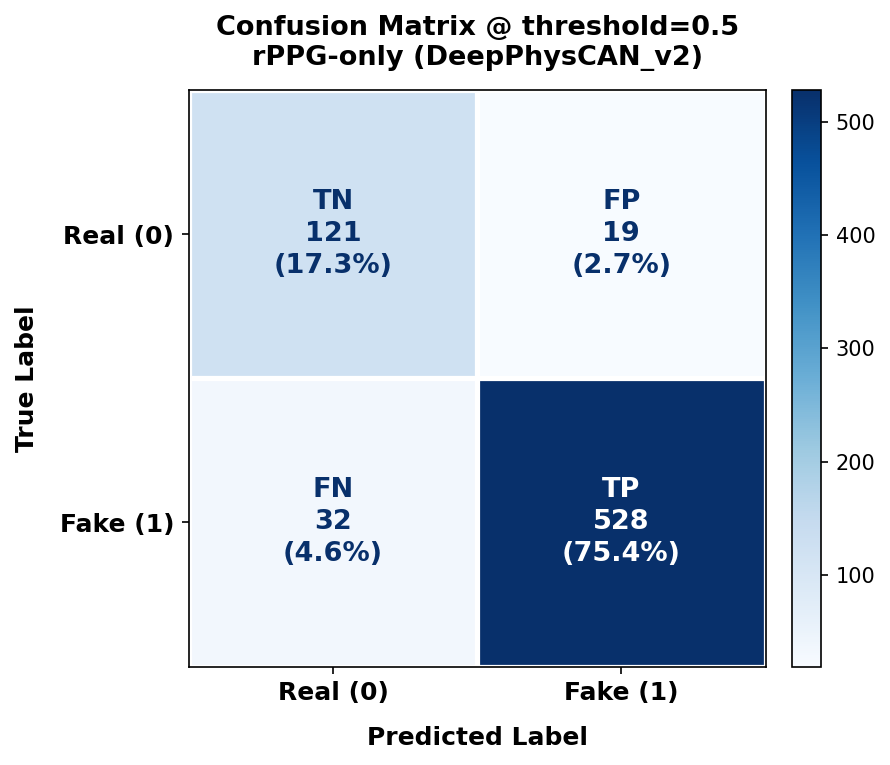

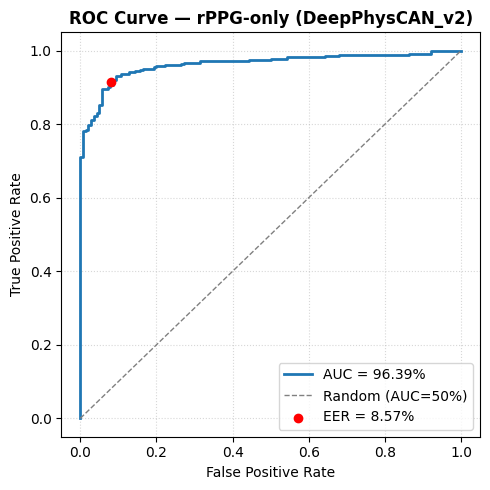

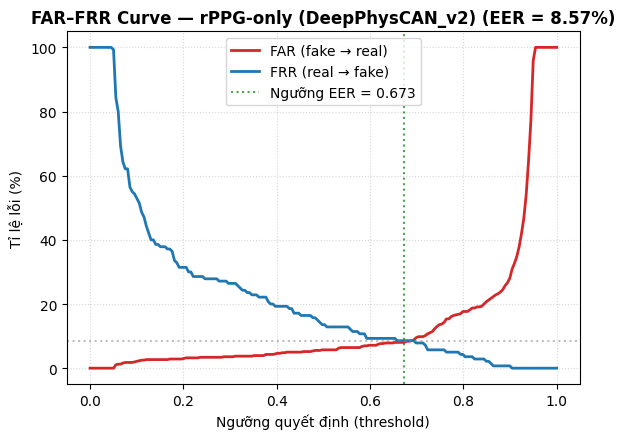


=== AUC/EER by method ===
        method  n_real  n_fake      auc      eer
NeuralTextures     140     140 0.936990 0.107143
     Face2Face     140     140 0.970510 0.078571
      FaceSwap     140     140 0.972908 0.078571
     Deepfakes     140     140 0.975000 0.057143

✓ Đã lưu /kaggle/working/rppg_can_branch/test_results_standalone.csv
⚠️  Khi đóng gói Kaggle Dataset mới, đặt CẢ 2 file (rppg_can_best.pth + test_results_standalone.csv) CÙNG 1 THƯ MỤC.


In [6]:
MODEL_NAME = "rPPG-only (DeepPhysCAN_v2)"

@torch.no_grad()
def evaluate_with_tta(eval_model, loader, use_tta=True):
    eval_model.eval()
    y_true, y_score = [], []
    for app_clip, mot_clip, label, vid in tqdm(loader, desc="Test"):
        app_clip, mot_clip = app_clip.to(DEVICE), mot_clip.to(DEVICE)
        logits_orig = eval_model(app_clip, mot_clip)
        if use_tta:
            logits_flip = eval_model(torch.flip(app_clip, dims=[4]), torch.flip(mot_clip, dims=[4]))
            prob = (torch.sigmoid(logits_orig) + torch.sigmoid(logits_flip)) / 2.0
        else:
            prob = torch.sigmoid(logits_orig)
        y_score.append(prob.item())
        y_true.append(label.item())
    return np.array(y_true), np.array(y_score)


ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
final_model = DeepPhysCAN_v2().to(DEVICE)
final_model.load_state_dict(ckpt["model_state"])
print(f"Nạp best checkpoint: epoch={ckpt['epoch']} (val_auc={ckpt['val_metrics']['auc']:.4f})")

y_true, y_score = evaluate_with_tta(final_model, test_loader, use_tta=True)
test_metrics = calc_metrics(y_true, y_score)

print(f"\n=== KẾT QUẢ TEST (FF++ C23) — {MODEL_NAME} (TTA={TTA_USED}) ===")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")
print(f"FAR @ EER           : {test_metrics['far_at_eer']*100:.2f}%  |  FRR @ EER : {test_metrics['frr_at_eer']*100:.2f}%")

cm = test_metrics["cm_at_0.5"]
print(f"\nConfusion Matrix @ 0.5:  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

# ---- Confusion Matrix CHUẨN HÓA (không đè chữ, hiển thị TN/FP/FN/TP + % rõ ràng) ----
fig, ax = plt.subplots(figsize=(6.0, 5.2), dpi=150)
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)
classes = ["Real (0)", "Fake (1)"]
ax.set_xticks([0, 1]); ax.set_xticklabels(classes, fontsize=12, fontweight="bold")
ax.set_yticks([0, 1]); ax.set_yticklabels(classes, fontsize=12, fontweight="bold")
total = np.sum(cm); thresh = cm.max() / 2.0
labels_tag = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = count / total * 100 if total > 0 else 0
        tag = labels_tag[i][j]
        color = "white" if count > thresh else "#08306b"
        text = f"{tag}\n{count:,}\n({pct:.1f}%)"
        ax.text(j, i, text, ha="center", va="center", color=color,
                fontsize=13, fontweight="bold", linespacing=1.3)
ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title(f"Confusion Matrix @ threshold=0.5\n{MODEL_NAME}",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2.5)
ax.tick_params(which="minor", bottom=False, left=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()

# ---- ROC curve ----
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2, color="#1f77b4",
        label=f"AUC = {test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random (AUC=50%)")
ax.scatter([test_metrics["far_at_eer"]], [1 - test_metrics["frr_at_eer"]], color="red", zorder=5,
           label=f"EER = {test_metrics['eer']*100:.2f}%")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {MODEL_NAME}", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

# ---- FAR-FRR curve ----
thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thr, fars * 100, lw=2, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", alpha=0.7,
           label=f"Ngưỡng EER = {test_metrics['eer_threshold']:.3f}")
ax.axhline(test_metrics["eer"] * 100, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Ngưỡng quyết định (threshold)"); ax.set_ylabel("Tỉ lệ lỗi (%)")
ax.set_title(f"FAR–FRR Curve — {MODEL_NAME} (EER = {test_metrics['eer']*100:.2f}%)", fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=150)
plt.show()

# ---- Breakdown theo method ----
test_ordered = test_df.reset_index(drop=True)
assert len(test_ordered) == len(y_true)
rows = []
real_mask = test_ordered["label"].values == 0
for method in sorted(test_ordered.loc[~real_mask, "method"].unique()):
    mm = test_ordered["method"].values == method
    sel = real_mask | mm
    m = calc_metrics(y_true[sel], y_score[sel])
    rows.append({"method": method, "n_real": int(real_mask.sum()),
                 "n_fake": int(mm.sum()), "auc": m["auc"], "eer": m["eer"]})
bd = pd.DataFrame(rows).sort_values("auc")
bd.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)
print("\n=== AUC/EER by method ===")
print(bd.to_string(index=False))

# ---- Lưu test_results_standalone.csv ----
gpu_hours = MANUAL_GPU_HOURS if MANUAL_GPU_HOURS is not None else float("nan")
standalone_row = {
    "model": MODEL_NAME, "input_modality": "rppg",
    "params_M": round(sum(p.numel() for p in final_model.parameters()) / 1e6, 2),
    "epochs_planned": 60, "epochs_run": ckpt["epoch"],
    "best_epoch": f"{ckpt['epoch']}|used_ema={ckpt.get('used_ema','?')}",
    "checkpoint_criterion": CHECKPOINT_CRITERION, "tta_used": TTA_USED, "gpu_hours": gpu_hours,
    "acc_intra": test_metrics["acc"], "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
}
pd.DataFrame([standalone_row]).to_csv(os.path.join(OUT_DIR, "test_results_standalone.csv"), index=False)
print(f"\n✓ Đã lưu {OUT_DIR}/test_results_standalone.csv")
if MANUAL_GPU_HOURS is None:
    print("⚠️  gpu_hours=NaN vì đây là session eval-only, không có log thời gian train thật. "
          "Nếu nhớ tổng thời gian chạy (xem tab Version/Output của lần train trước), điền vào "
          "MANUAL_GPU_HOURS ở Mục 1 rồi chạy lại cell này.")
print("⚠️  Khi đóng gói Kaggle Dataset mới, đặt CẢ 2 file "
      "(rppg_can_best.pth + test_results_standalone.csv) CÙNG 1 THƯ MỤC.")


Đã tải /kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/train_history.csv — 60 epochs


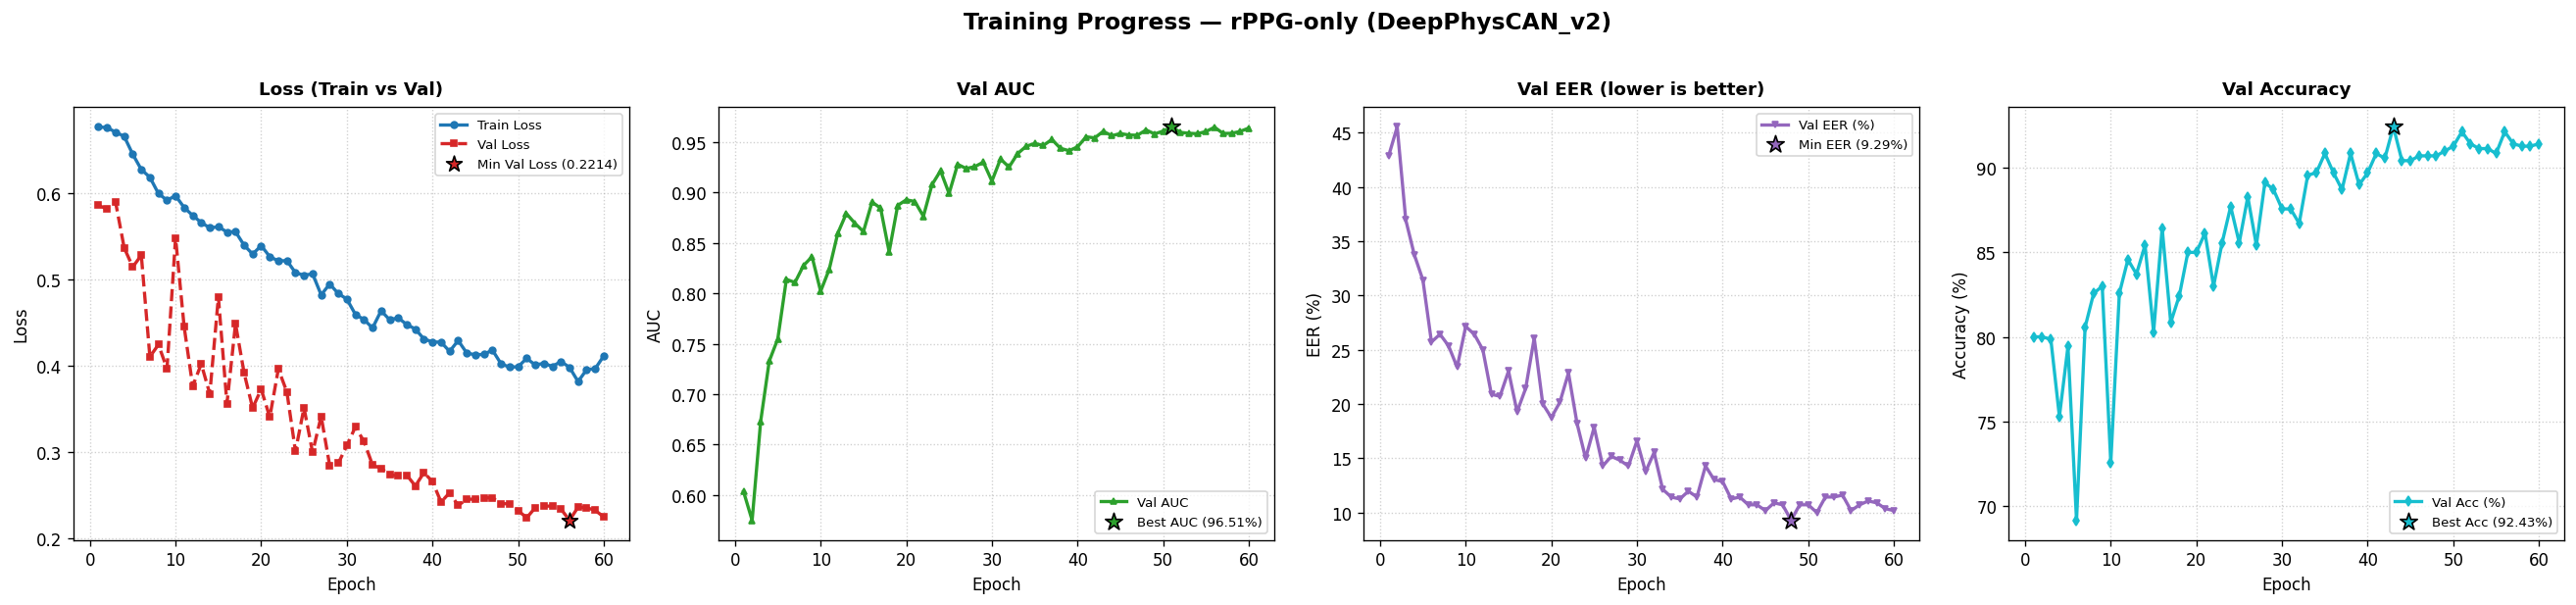

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Vẽ Training Curves CHUẨN HÓA — đồng bộ với tất cả các mô hình khác
# ═══════════════════════════════════════════════════════════════════════════════

if os.path.exists(TRAIN_HISTORY_CSV):
    hist_df = pd.read_csv(TRAIN_HISTORY_CSV)
    print(f"Đã tải {TRAIN_HISTORY_CSV} — {len(hist_df)} epochs")

    epochs = hist_df["epoch"].values
    train_loss = hist_df["train_loss"].values if "train_loss" in hist_df.columns else None

    val_loss, vl_label = None, "Val Loss"
    for col in ["val_loss", "val_loss_ema", "val_loss_raw"]:
        if col in hist_df.columns:
            val_loss = hist_df[col].values
            if "ema" in col: vl_label = "Val Loss (EMA)"
            elif "raw" in col: vl_label = "Val Loss (Raw)"
            break

    val_auc = None
    for col in ["val_auc", "val_auc_ema", "val_auc_raw"]:
        if col in hist_df.columns:
            val_auc = hist_df[col].values; break

    val_eer = None
    for col in ["val_eer", "val_eer_ema", "val_eer_raw"]:
        if col in hist_df.columns:
            val_eer = hist_df[col].values; break

    val_acc = None
    for col in ["val_acc", "val_acc_ema", "val_acc_raw"]:
        if col in hist_df.columns:
            val_acc = hist_df[col].values; break

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), dpi=120)

    # Panel 1: Train Loss vs Val Loss
    ax = axes[0]
    if train_loss is not None:
        ax.plot(epochs, train_loss, "o-", color="#1f77b4", lw=2, ms=4, label="Train Loss")
    if val_loss is not None:
        ax.plot(epochs, val_loss, "s--", color="#d62728", lw=2, ms=4, label=vl_label)
        best_i = int(np.argmin(val_loss))
        ax.scatter([epochs[best_i]], [val_loss[best_i]], color="#d62728", s=100, zorder=5,
                   edgecolors="black", marker="*", label=f"Min Val Loss ({val_loss[best_i]:.4f})")
    ax.set_title("Loss (Train vs Val)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")

    # Panel 2: Val AUC
    ax = axes[1]
    if val_auc is not None:
        ax.plot(epochs, val_auc, "^-", color="#2ca02c", lw=2, ms=4, label="Val AUC")
        best_i = int(np.argmax(val_auc))
        ax.scatter([epochs[best_i]], [val_auc[best_i]], color="#2ca02c", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best AUC ({val_auc[best_i]*100:.2f}%)")
    ax.set_title("Val AUC", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")

    # Panel 3: Val EER
    ax = axes[2]
    if val_eer is not None:
        ax.plot(epochs, val_eer * 100, "v-", color="#9467bd", lw=2, ms=4, label="Val EER (%)")
        best_i = int(np.argmin(val_eer))
        ax.scatter([epochs[best_i]], [val_eer[best_i] * 100], color="#9467bd", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Min EER ({val_eer[best_i]*100:.2f}%)")
    ax.set_title("Val EER (lower is better)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("EER (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")

    # Panel 4: Val Accuracy
    ax = axes[3]
    if val_acc is not None:
        ax.plot(epochs, val_acc * 100, "d-", color="#17becf", lw=2, ms=4, label="Val Acc (%)")
        best_i = int(np.argmax(val_acc))
        ax.scatter([epochs[best_i]], [val_acc[best_i] * 100], color="#17becf", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best Acc ({val_acc[best_i]*100:.2f}%)")
    ax.set_title("Val Accuracy", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")

    plt.suptitle(f"Training Progress — {MODEL_NAME}",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=200, bbox_inches='tight')
    plt.show()
else:
    print(f"⚠️ Không tìm thấy {TRAIN_HISTORY_CSV} — bỏ qua vẽ Training Curves.")
    print("   Nếu muốn vẽ, hãy thêm train_history.csv vào Kaggle Input cùng checkpoint.")
